In [1]:
pwd()

"/Users/lewis/Dropbox/Covid Modeling/Covid-ILM/notebooks"

In [3]:
using CovidSim_ilm

In [4]:
using StatsBase
using TypedTables
using BenchmarkTools
using Distributions
using YAML
using PrettyPrint
using Plots
# Plots.pyrcparams["backend"]="Qt5Agg"

# Test setup and population matrix

In [4]:
# set locale and number of days
locale = 38015
ndays = 180

180

In [5]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/source"))

In [6]:
alldat = setup(ndays, [locale]; 
    dovax=true,
    paramdir="../parameters", 
    geofilename="../data/geo2data.csv",
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml"
    );

In [7]:
keys(alldat)

(:dat, :transitionset, :geo, :vaxset, :vxschedset, :infectset, :social, :trvec)

In [8]:
alldat.dat

Dict{String, Dict{Int64, V} where V} with 4 entries:
  "agegrp_idx" => Dict{Int64, Dict{agegrp, Vector{Int64}}}(38015=>Dict(age0_19=…
  "newhistmx"  => Dict{Int64, Array{Int64, N} where N}(38015=>[0 0 … 0 0; 0 0 ……
  "popdat"     => Dict{Int64, Table{NamedTuple{(:pid, :status, :agegrp, :cond, …
  "cumhistmx"  => Dict{Int64, Array{Int64, N} where N}(38015=>[0 0 … 0 0; 0 0 ……

In [9]:
locdat = alldat.dat["popdat"][locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond     duration  variant  recovday  deadday  ⋯
    ┌─────────────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  notsick  0        default  0         0        ⋯
 2  │ 2    unexposed  age0_19  notsick  0        default  0         0        ⋯
 3  │ 3    unexposed  age0_19  notsick  0        default  0         0        ⋯
 4  │ 4    unexposed  age0_19  notsick  0        default  0         0        ⋯
 5  │ 5    unexposed  age0_19  notsick  0        default  0         0        ⋯
 6  │ 6    unexposed  age0_19  notsick  0        default  0         0        ⋯
 7  │ 7    unexposed  age0_19  notsick  0        default  0         0        ⋯
 8  │ 8    unexposed  age0_19  notsick  0        default  0         0        ⋯
 9  │ 9    unexposed  age0_19  notsick  0        default  0         0        ⋯
 10 │ 10   unexposed  age0_19  notsick  0        default  0         0        ⋯
 11 │ 11   un

In [10]:
locdat.vaxrcvd

95626-element Vector{Vector{Symbol}}:
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 ⋮
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]

In [11]:
ages = alldat.dat["agegrp_idx"][locale]

Dict{agegrp, Vector{Int64}} with 5 entries:
  age0_19  => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  23993, 23994, 23995, 23996, 23…
  age80_up => [91898, 91899, 91900, 91901, 91902, 91903, 91904, 91905, 91906, 9…
  age40_59 => [49918, 49919, 49920, 49921, 49922, 49923, 49924, 49925, 49926, 4…
  age60_79 => [74303, 74304, 74305, 74306, 74307, 74308, 74309, 74310, 74311, 7…
  age20_39 => [24003, 24004, 24005, 24006, 24007, 24008, 24009, 24010, 24011, 2…

In [12]:
columnnames(locdat)

(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday)

In [13]:
countmap(locdat.agegrp)

Dict{agegrp, Int64} with 5 entries:
  age0_19  => 24002
  age80_up => 3729
  age40_59 => 24385
  age60_79 => 17595
  age20_39 => 25915

In [14]:
countmap(locdat.status)  # everyone begins as unexposed

Dict{status, Int64} with 1 entry:
  unexposed => 95626

In [15]:
geodf = alldat.geo   # the date for all locales has been read into a dataframe

,fips,county,city,state,sizecat,pop,density,density_factor
,Int64,String1…,String1…,String3…,Int64,Int64,Int64,Float64
1,6075,San Francisco,San Francisco,CA,2,881549,17255,1.04109
2,53033,Seattle,Seattle,WA,2,2252782,5175,0.931603
3,36061,New York,New York,NY,1,8336817,40306,1.25
4,39035,Cuyahoga,Cleveland,OH,2,1235072,3063,0.912462
5,48113,Dallas,Dallas,TX,2,2635516,4000,0.920954
6,39151,Stark,Canton,OH,3,370606,1688,0.9
7,34013,Essex,Newark,NJ,3,798975,6396,0.942669
8,13089,DeKalb,Atlanta,GA,2,1063937,2708,0.909244
9,17167,Sangamon,Springfield,IL,3,194672,1747,0.900535


In [16]:
density_factor = geodf[geodf[!, :fips] .== locale, :density_factor][]

0.9042506085245222

In [17]:
pprintln(alldat.infectset[:base])  # the spread parameters are loaded as a dict of float arrays

Infectparams(
  sendrisk=[0.0, 0.3, 0.65, 0.75, 
            0.85, 0.85, 0.75, 0.7, 
            0.65, 0.6, 0.5, 0.2, 
            0.1, 0.1, 0.1, 0.05, 
            0.05, 0.0, 0.0, 0.0, 
            0.0, 0.0, 0.0, 0.0, 0.0],
  recvrisk=[0.1, 0.39, 0.44, 0.54, 
            0.56],
  immunestrength=0.6,
  immunehalflife=180,
)


In [18]:
alldat.social

CovidSim_ilm.Socialparams(1.0, Dict{Enum, Dict{Enum, Float64}}(age0_19 => Dict(nil => 1.1, sick => 0.7, severe => 0.5, mild => 1.1), age80_up => Dict(nil => 1.0, sick => 0.6, severe => 0.5, mild => 0.9), age40_59 => Dict(nil => 2.1, sick => 1.0, severe => 0.6, mild => 2.0), age60_79 => Dict(nil => 1.7, sick => 0.7, severe => 0.5, mild => 1.6), age20_39 => Dict(nil => 2.1, sick => 1.0, severe => 0.6, mild => 2.0)), Dict{Enum, Dict{Enum, Float64}}(age0_19 => Dict(recovered => 0.55, nil => 0.55, sick => 0.28, severe => 0.18, mild => 0.55, unexposed => 0.55), age80_up => Dict(recovered => 0.35, nil => 0.35, sick => 0.18, severe => 0.18, mild => 0.28, unexposed => 0.35), age40_59 => Dict(recovered => 0.61, nil => 0.61, sick => 0.3, severe => 0.18, mild => 0.58, unexposed => 0.61), age60_79 => Dict(recovered => 0.41, nil => 0.41, sick => 0.18, severe => 0.18, mild => 0.41, unexposed => 0.41), age20_39 => Dict(recovered => 0.63, nil => 0.63, sick => 0.35, severe => 0.18, mild => 0.62, unexpos

In [19]:
fieldnames(typeof(alldat.social))

(:gammashape, :contactfactors, :touchfactors)

In [20]:
contactfactors = alldat.social.contactfactors

Dict{Enum, Dict{Enum, Float64}} with 5 entries:
  age0_19  => Dict(nil=>1.1, sick=>0.7, severe=>0.5, mild=>1.1)
  age80_up => Dict(nil=>1.0, sick=>0.6, severe=>0.5, mild=>0.9)
  age40_59 => Dict(nil=>2.1, sick=>1.0, severe=>0.6, mild=>2.0)
  age60_79 => Dict(nil=>1.7, sick=>0.7, severe=>0.5, mild=>1.6)
  age20_39 => Dict(nil=>2.1, sick=>1.0, severe=>0.6, mild=>2.0)

In [21]:
typeof(contactfactors)

Dict{Enum, Dict{Enum, Float64}}

In [22]:
contactfactors[age80_up]

Dict{Enum, Float64} with 4 entries:
  nil    => 1.0
  sick   => 0.6
  severe => 0.5
  mild   => 0.9

In [23]:
touchfactors =  alldat.social.touchfactors

Dict{Enum, Dict{Enum, Float64}} with 5 entries:
  age0_19  => Dict(recovered=>0.55, nil=>0.55, sick=>0.28, severe=>0.18, mild=>…
  age80_up => Dict(recovered=>0.35, nil=>0.35, sick=>0.18, severe=>0.18, mild=>…
  age40_59 => Dict(recovered=>0.61, nil=>0.61, sick=>0.3, severe=>0.18, mild=>0…
  age60_79 => Dict(recovered=>0.41, nil=>0.41, sick=>0.18, severe=>0.18, mild=>…
  age20_39 => Dict(recovered=>0.63, nil=>0.63, sick=>0.35, severe=>0.18, mild=>…

In [24]:
touchfactors[age40_59]

Dict{Enum, Float64} with 6 entries:
  recovered => 0.61
  nil       => 0.61
  sick      => 0.3
  severe    => 0.18
  mild      => 0.58
  unexposed => 0.61

In [25]:
limdict = CovidSim_ilm.limdict
limdict(touchfactors, <)  # recursive minimum

0.18

In [26]:
alldat.vaxset

Dict{Any, Any} with 3 entries:
  :Moderna => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Moderna, 2, 2…
  :Pfizer  => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Pfizer, 2, 21…
  :JnJ     => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:JnJ, 1, 0, 24…

In [27]:
# is shifter working?
shifter(touchfactors, (.18, .3)...)[age40_59]

Dict{Enum, Float64} with 6 entries:
  recovered => 0.294667
  nil       => 0.294667
  sick      => 0.212
  severe    => 0.18
  mild      => 0.286667
  unexposed => 0.294667

In [28]:
dectree = alldat.transitionset[:base] # the decision trees for all age groups are loaded

Dict{agegrp, Dict{Int64, Dict{Symbol, Any}}} with 5 entries:
  age0_19  => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age80_up => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age40_59 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age60_79 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age20_39 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …

In [29]:
transarr = alldat.transitionset[:base]

Dict{agegrp, Dict{Int64, Dict{Symbol, Any}}} with 5 entries:
  age0_19  => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age80_up => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age40_59 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age60_79 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age20_39 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …

In [30]:
transarr[age0_19]

Dict{Int64, Dict{Symbol, Any}} with 5 entries:
  5 => Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.976 0.0 … 0.0…
  4 => Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0…
  2 => Dict(:transition=>[0.9 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.05 …
  3 => Dict(:transition=>[1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.85 0.0 … 0.03…
  1 => Dict(:transition=>[0.0 0.4 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0…

In [31]:
transarr[age0_19][1]

Dict{Symbol, Any} with 2 entries:
  :transition => [0.0 0.4 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 …
  :duration    => 5

In [32]:
transarr[age0_19][1][:transition]

4×6 OffsetArray(::Matrix{Float64}, 5:8, 1:6) with eltype Float64 with indices 5:8×1:6:
 0.0  0.4  0.5  0.1  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0

In [33]:
tr_age0_19 = transarr[age0_19]
T = typeof(tr_age0_19[1][:transition])
supertype(T)

AbstractMatrix{Float64} (alias for AbstractArray{Float64, 2})

In [34]:
trvec = zeros(6)
p_cond = mild
p_duration = 9
trvec = CovidSim_ilm.has(tr_age0_19, p_duration, p_cond, trvec)
println(typeof(trvec))
trvec



Vector{Float64}


6-element Vector{Float64}:
 0.0
 0.0
 1.0
 0.0
 0.0
 0.0

In [35]:
typeof(dectree)

Dict{agegrp, Dict{Int64, Dict{Symbol, Any}}}

Dict{Int64, OrderedCollections.OrderedDict{Int, Dict{String, Vector{T} where T}

In [36]:
dectree[age80_up]

Dict{Int64, Dict{Symbol, Any}} with 5 entries:
  5 => Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.682 0.0 … 0.0…
  4 => Dict(:transition=>[1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0…
  2 => Dict(:transition=>[0.5 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.4 0…
  3 => Dict(:transition=>[0.7 0.0 … 0.0 0.0; 0.7 0.0 … 0.0 0.0; 0.7 0.0 … 0.2 0…
  1 => Dict(:transition=>[0.0 0.1 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0…

In [37]:
typeof(dectree[age80_up][5][:transition])

OffsetArrays.OffsetMatrix{Float64, Matrix{Float64}} (alias for OffsetArrays.OffsetArray{Float64, 2, Array{Float64, 2}})

## Let's look at the decay rate of immunity gained by recovering

In [123]:
CovidSim_ilm.risk(alldat.infectset, alldat.vaxset, locdat, 20, 200)
infectset, vaxset, locdat, spreader, target

LoadError: BoundsError: attempt to access 25-element Vector{Float64} at index [0]

# Load vaccine parameters

In [124]:
# mapping for all vaccines to parameters for each vaccine
vaccines = YAML.load_file("../parameters/vaccines.yml"; dicttype=Dict{Symbol,Any})

Dict{Symbol, Any} with 3 entries:
  :Moderna => Dict{Symbol, Any}(:directory_name=>"moderna", :transition_fname=>…
  :Pfizer  => Dict{Symbol, Any}(:directory_name=>"pfizer", :transition_fname=>"…
  :JnJ     => Dict{Symbol, Any}(:directory_name=>"jnj", :transition_fname=>"jnj…

In [125]:
vaccines[:Pfizer]

Dict{Symbol, Any} with 3 entries:
  :directory_name   => "pfizer"
  :transition_fname => "pfizer_transition.yml"
  :infect_fname     => "pfizer_spread.yml"

In [126]:
vaxkeys = keys(vaccines)

KeySet for a Dict{Symbol, Any} with 3 entries. Keys:
  :Moderna
  :Pfizer
  :JnJ

In [127]:
vaccines[:Pfizer]

Dict{Symbol, Any} with 3 entries:
  :directory_name   => "pfizer"
  :transition_fname => "pfizer_transition.yml"
  :infect_fname     => "pfizer_spread.yml"

### Other vaccine parameters

In [128]:
vax = :Moderna
v = YAML.load_file(joinpath("../parameters","vaccine_parameters",vaccines[vax][:directory_name],
        vaccines[vax][:infect_fname]), dicttype=Dict{Symbol, Any})

Dict{Symbol, Any} with 7 entries:
  :day1_effect      => 0.5
  :reqdshots        => 2
  :halflife         => 280
  :name             => "Moderna"
  :delay2ndshot     => 21
  :full_effect_days => 14
  :effectiveness    => Dict{Symbol, Any}(:first=>Dict{Symbol, Any}(:alpha=>0.92…

In [129]:
vaxset = CovidSim_ilm.build_vaxset("vaccines.yml", paramdir="../parameters")

Dict{Any, Any} with 3 entries:
  :Moderna => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Moderna, 2, 2…
  :Pfizer  => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Pfizer, 2, 21…
  :JnJ     => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:JnJ, 1, 0, 24…

### Vaccination Schedule

In [130]:
vxschedset = CovidSim_ilm.build_vaxschedset()

Dict{Symbol, Vaxsched} with 1 entry:
  :us1 => Vaxsched(Dict{Symbol, Vaxinclude}(:Moderna=>Vaxinclude(0.3, 450000, 0…

In [131]:
println(typeof(vxschedset))
pprint(vxschedset)

Dict{Symbol, Vaxsched}
{
  :us1 : Vaxsched(
           vaxesincluded={
                           :Moderna : Vaxinclude(
                                        mix=0.3,
                                        doses=450000,
                                        pct2ndshot=0.85,
                                        alternate=["Pfizer", 
                                                   "JnJ"],
                                        booster=false,
                                      ),
                           :Pfizer : Vaxinclude(
                                       mix=0.55,
                                       doses=500000,
                                       pct2ndshot=0.85,
                                       alternate=["Moderna", 
                                                  "JnJ"],
                                       booster=false,
                                     ),
                           :JnJ : Vaxinclude(
                                   

In [132]:
asched = first(keys(vxschedset))

:us1

In [133]:
vxschedset[asched].dayrange

360:700

In [134]:
sum([vxschedset[asched].pctfunc(i) for i in vxschedset[asched].dayrange])

0.649155

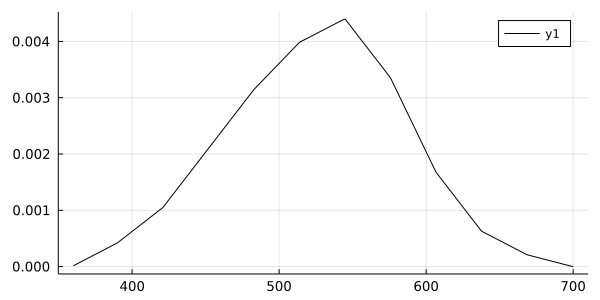

In [135]:
plot(vxschedset[asched].dayrange, [vxschedset[asched].pctfunc(i) for i in vxschedset[asched].dayrange],size=(600,300))

# Give some shots

In [136]:
peeps = 301:400
cnt = length(peeps)
day_ctr[:day] = 500  # must be in the range of the schedule
vaccinate!(locdat, vxschedset, peeps, vaxset)

(people_today, pctfunc(today), length(contactable_idx)) = (0, 0.0036100580645161296, 100)


In [137]:
any(last.(locdat.vaxrcvd) .!= :none)

false

#### Reset the give shots test

In [138]:
locdat.vaxstatus[peeps] = fill(:none, cnt)
locdat.vaxday[peeps] = fill([0], cnt)
locdat.vaxrcvd[peeps] = fill([:none], cnt)

100-element Vector{Vector{Symbol}}:
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 ⋮
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]

# Create a seed case

In [7]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, nil, :base, agegrps)

(::CovidSim_ilm.var"#runcase#74"{CovidSim_ilm.var"#runcase#73#75"{Int64, Vector{Int64}, Int64, condition, Symbol, NTuple{5, agegrp}}}) (generic function with 1 method)

# Run a simulation

In [5]:
locale = 38015
ndays = 180
model = buildsim(ndays, locale; 
    dovax=false, 
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml",
);

In [8]:
popdat, series = runsim(model; 
    dovax=false, 
    dovariant=false,
    showr0=false, 
    silent=true, 
    runcases=[seed_1_6]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.14053037699999993, 0, 0.5396600830000001, 0.3801904610000001, 0.7809870760000002)


In [8]:
keys(popdat)

KeySet for a Dict{Int64, TypedTables.Table{NamedTuple{(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday), Tuple{Int64, status, agegrp, condition, Int64, Symbol, Int64, Int64, Int64, Symbol, Symbol, Vector{Symbol}, Vector{Int64}, Int64, Bool, Int64, Bool, Int64}}, 1, NamedTuple{(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday), Tuple{Vector{Int64}, Vector{status}, Vector{agegrp}, Vector{condition}, Vector{Int64}, Vector{Symbol}, Vector{Int64}, Vector{Int64}, Vector{Int64}, Vector{Symbol}, Vector{Symbol}, Vector{Vector{Symbol}}, Vector{Vector{Int64}}, Vector{Int64}, BitVector, Vector{Int64}, BitVector, Vector{Int64}}}}} with 1 entry. Keys:
  38015

In [156]:
rf(x) = CovidSim_ilm.sigmoid(shifter(clamp(x, 0.0, 2.0), 0.0, 2.0, -4.5, 4.5))  

rf (generic function with 1 method)

In [157]:
rf(2.0)

0.9890130573694068

In [8]:
keys(model[:dat])

KeySet for a Dict{String, Dict{Int64}} with 4 entries. Keys:
  "agegrp_idx"
  "newhistmx"
  "popdat"
  "cumhistmx"

In [9]:
popdat = model[:dat]["popdat"][locale]

Table with 18 columns and 95626 rows:
      pid  status      agegrp   cond        duration  variant  recovday  ⋯
    ┌────────────────────────────────────────────────────────────────────
 1  │ 1    recovered   age0_19  sick        14       base     98        ⋯
 2  │ 2    unexposed   age0_19  uninfected  0        base     0         ⋯
 3  │ 3    recovered   age0_19  nil         9        base     107       ⋯
 4  │ 4    unexposed   age0_19  uninfected  0        base     0         ⋯
 5  │ 5    unexposed   age0_19  uninfected  0        base     0         ⋯
 6  │ 6    unexposed   age0_19  uninfected  0        base     0         ⋯
 7  │ 7    recovered   age0_19  mild        14       base     91        ⋯
 8  │ 8    unexposed   age0_19  uninfected  0        base     0         ⋯
 9  │ 9    unexposed   age0_19  uninfected  0        base     0         ⋯
 10 │ 10   recovered   age0_19  nil         9        base     105       ⋯
 11 │ 11   unexposed   age0_19  uninfected  0        base     0         ⋯

In [10]:
countmap(popdat.cond)

Dict{condition, Int64} with 5 entries:
  uninfected => 17279
  sick       => 18803
  severe     => 3576
  nil        => 15225
  mild       => 40743

In [11]:
countmap(popdat.status)

Dict{status, Int64} with 4 entries:
  dead       => 1273
  unexposed  => 17279
  infectious => 3793
  recovered  => 73281

In [12]:
virus_outcome(series, locale, base=:pop)

Dict{Symbol, Float64} with 4 entries:
  :infectious => 0.0396649
  :dead       => 0.0133123
  :recovered  => 0.766329
  :unexposed  => 0.180694

In [13]:
series[locale][:cum]

180×108 Matrix{Int64}:
 24002  25912  24382  17595  3729  …  0  0  0  0  0  0  0  0  0  0  0  0
 24002  25912  24382  17595  3729     0  0  0  0  0  0  0  0  0  0  0  0
 24002  25912  24382  17595  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24002  25911  24381  17595  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24001  25910  24381  17594  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25909  24381  17594  3728  …  0  0  0  0  0  0  0  0  0  0  0  0
 24000  25908  24381  17593  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25908  24380  17593  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25908  24380  17592  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25908  24380  17592  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25908  24380  17592  3728  …  0  0  0  0  0  0  0  0  0  0  0  0
 24000  25908  24379  17592  3727     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25907  24378  17592  3727     0  0  0  0  0  0  0  0  0  0  0  0
     ⋮                      

# Plot results

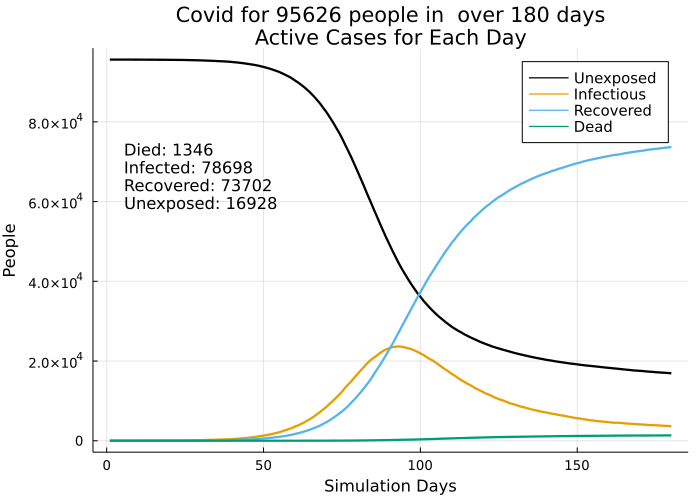

In [9]:
cumplot(series, locale)

Note that the orangle line labeled Infectious that shows the number of infected people is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: Some people got sick today. Some people get better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. Newspaper tracking shows the new active infections of each day--who got sick today? The next day, if no one new got sick the line would be at zero--even though the people who got sick aren't better yet. So, the newspaper line goes up and down faster. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line is high but levels off. This is the least common way to show the data.

## Run simulation with full vaccination schedule

In [10]:
ndays = 720
model = buildsim(ndays, locale; 
    dovax=true, 
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml",
);

In [1]:
series = runsim(model; 
    dovax=true, 
    dovariant=false,
    showr0=false, 
    silent=true, 
    runcases=[seed_1_6]);

LoadError: UndefVarError: seed_1_6 not defined

In [19]:
locdat = popdat[locale]
vaxcols = @Select(vaxrcvd, vaxstatus)(locdat)

Table with 2 columns and 95626 rows:
      vaxrcvd     vaxstatus
    ┌──────────────────────
 1  │ [:Moderna]  first
 2  │ [:Moderna]  first
 3  │ [:Moderna]  first
 4  │ [:Pfizer]   first
 5  │ [:Pfizer]   first
 6  │ [:Pfizer]   first
 7  │ [:JnJ]      full
 8  │ [:Pfizer]   first
 9  │ [:Moderna]  first
 10 │ [:JnJ]      full
 11 │ [:Moderna]  first
 12 │ [:Pfizer]   first
 13 │ [:Pfizer]   first
 14 │ [:Moderna]  first
 15 │ [:Pfizer]   first
 16 │ [:JnJ]      full
 17 │ [:JnJ]      full
 18 │ [:Pfizer]   first
 19 │ [:Moderna]  first
 20 │ [:Moderna]  first
 21 │ [:Pfizer]   first
 22 │ [:Moderna]  first
 23 │ [:Moderna]  first
 ⋮  │     ⋮           ⋮

In [68]:
pfizer2shots = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 2) ? 2 
            : 0, vaxcols.vaxrcvd))
pfizer1shots = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplepfizer2 = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 2) ? 1 
            : 0, vaxcols.vaxrcvd))
peoplepfizer1 = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

moderna2shots = sum(map(v -> (first(v) == :Moderna) & (length(v) == 2) ? 2 
            : 0, vaxcols.vaxrcvd))
moderna1shots = sum(map(v -> (first(v) == :Moderna) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplemoderna2 = sum(map(v -> (first(v) == :Moderna) & (length(v) == 2) ? 1 
            : 0, vaxcols.vaxrcvd))
peoplemoderna1 = sum(map(v -> (first(v) == :Moderna) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplejnj = jnjshots = sum(map(v -> (first(v) == :JnJ) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peopleatleast1shot = (peoplepfizer2 + peoplepfizer1 + peoplemoderna2 + peoplemoderna1 +
                    peoplejnj)

peoplefull = count(vaxcols.vaxstatus .== :full) 

@show pfizer2shots, pfizer1shots
@show peoplepfizer2, peoplepfizer1

@show moderna2shots, moderna1shots
@show peoplemoderna2, peoplemoderna1

@show jnjshots

@show peopleatleast1shot, peoplefull

LoadError: UndefVarError: vaxcols not defined

In [69]:
count(vaxcols.vaxstatus .== :full)

LoadError: UndefVarError: vaxcols not defined

In [70]:
count(vaxcols.vaxstatus .== :first)

LoadError: UndefVarError: vaxcols not defined

## Test a social distancing case

In [21]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [22]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [20]:
ndays = 720
model = buildsim(ndays, locale; 
    dovax=true, 
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml",
);

vaxlist = [:Moderna, :Pfizer, :JnJ]


In [23]:
series = runsim(model, ndays, locale;
            dovax=true,
            showr0=false, 
            silent=true, 
            runcases=[seed_1_6, sd1, sd1_end]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.11795433100000015, 0.02162744100000001, 0.021421842000000104, 0.03524409200000001, 1.7641734699999978)


In [24]:
virus_outcome(series, locale, base=:pop)

Dict{Symbol, Float64} with 4 entries:
  :infectious => 0.0
  :dead       => 0.000941167
  :recovered  => 0.0643863
  :unexposed  => 0.934673

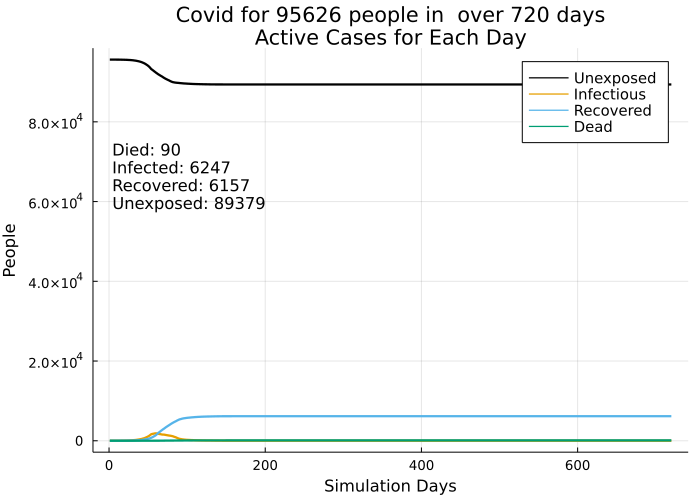

In [25]:
cumplot(series, locale)

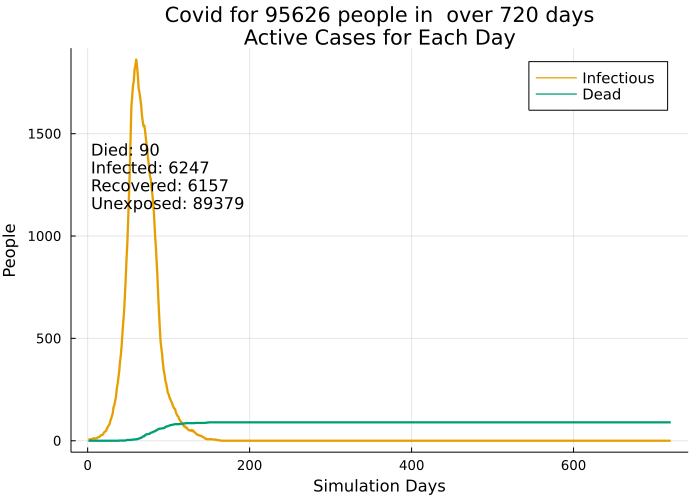

In [26]:
cumplot(series, locale,[:infectious, :dead])

In [77]:
outdat = result_dict[:dat]["popdat"][locale]
all(outdat.sdcomply .== :none)

LoadError: UndefVarError: result_dict not defined

## Social distancing only among those age40_59, age60_79, age80_plus

In [31]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [30]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [34]:
ndays = 720
model = buildsim(ndays, locale; 
    dovax=true, 
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml",
);

In [35]:
popdat, series = runsim(model, ndays;
                    dovax = false,
                    showr0=false, 
                    silent=true, 
                    runcases=[seed_1_6, sdolder, sdolder_end]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.16620946100000014, 0, 1.1953215340000007, 0.9240672879999997, 1.1589701540000004)


In [81]:
olderdat = result_dict[:dat]["popdat"][locale]

sd = findall(olderdat.sdcomply .!= :none)

@Select(agegrp, sdcomply)(olderdat[sd])

LoadError: UndefVarError: result_dict not defined

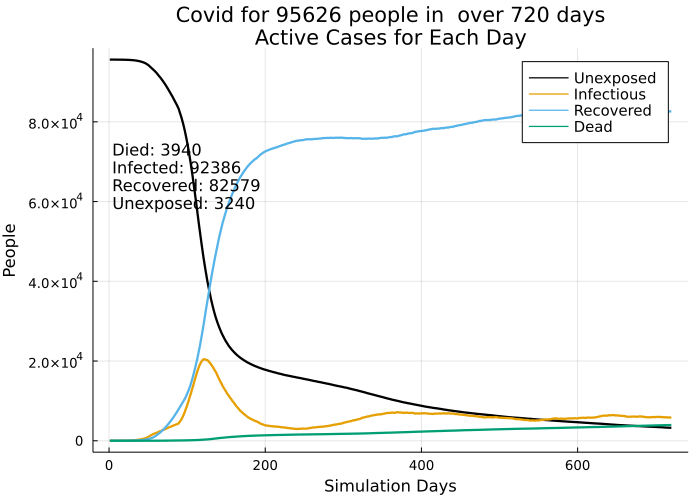

In [36]:
cumplot(series, locale)

In [83]:
cumplot(series, locale, [:infectious, :dead])

LoadError: UndefVarError: series not defined

## Social Distancing starts with everyone and then the younger folks party

In [37]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [40]:
popdat, series = runsim(model; 
            showr0=false, 
            silent=true, 
            runcases=[seed_1_6, sd1, sdyoung_end]
            );

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.1323647909999998, 0, 0.351595745, 0.30308787099999995, 1.117158226999999)


In [41]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcomply .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [42]:
youngtab = Table(mixdat[young])
count(youngtab.sdcomply .== :none)

49917

In [43]:
oldtab = Table(mixdat[old])
count(oldtab.sdcomply .!= :none)

40974

In [44]:
typeof(mixdat.agegrp)

Vector{agegrp} (alias for Array{agegrp, 1})

In [45]:
mixdat = model[:dat]["popdat"][locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  uninfected  0        base     0         ⋯
 2  │ 2    recovered  age0_19  sick        14       base     152       ⋯
 3  │ 3    unexposed  age0_19  uninfected  0        base     0         ⋯
 4  │ 4    unexposed  age0_19  uninfected  0        base     0         ⋯
 5  │ 5    recovered  age0_19  nil         9        base     559       ⋯
 6  │ 6    unexposed  age0_19  uninfected  0        base     0         ⋯
 7  │ 7    unexposed  age0_19  uninfected  0        base     0         ⋯
 8  │ 8    recovered  age0_19  mild        14       base     705       ⋯
 9  │ 9    recovered  age0_19  nil         9        base     316       ⋯
 10 │ 10   recovered  age0_19  nil         9        base     405       ⋯
 11 │ 11   recovered  age0_19  nil         9        base     291       ⋯
 12 │ 12   r

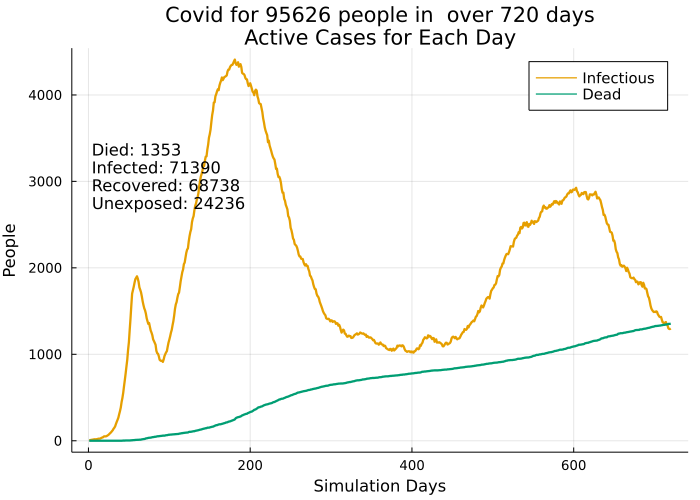

In [46]:
cumplot(series, locale, [:infectious, :dead])

In [92]:
@Select(status, agegrp, cond, sdcomply)(locdat)

Table with 4 columns and 95626 rows:
      status     agegrp   cond     sdcomply
    ┌──────────────────────────────────────
 1  │ unexposed  age0_19  notsick  none
 2  │ unexposed  age0_19  notsick  none
 3  │ unexposed  age0_19  notsick  none
 4  │ unexposed  age0_19  notsick  none
 5  │ unexposed  age0_19  notsick  none
 6  │ unexposed  age0_19  notsick  none
 7  │ unexposed  age0_19  notsick  none
 8  │ unexposed  age0_19  notsick  none
 9  │ unexposed  age0_19  notsick  none
 10 │ unexposed  age0_19  notsick  none
 11 │ unexposed  age0_19  notsick  none
 12 │ unexposed  age0_19  notsick  none
 13 │ unexposed  age0_19  notsick  none
 14 │ unexposed  age0_19  notsick  none
 15 │ unexposed  age0_19  notsick  none
 16 │ unexposed  age0_19  notsick  none
 17 │ unexposed  age0_19  notsick  none
 18 │ unexposed  age0_19  notsick  none
 19 │ unexposed  age0_19  notsick  none
 20 │ unexposed  age0_19  notsick  none
 21 │ unexposed  age0_19  notsick  none
 22 │ unexposed  age0_19  notsick  

alldat

In [93]:
alldat

(dat = Dict{String, Dict{Int64, V} where V}("agegrp_idx" => Dict{Int64, Dict{agegrp, Vector{Int64}}}(38015 => Dict(age0_19 => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  23993, 23994, 23995, 23996, 23997, 23998, 23999, 24000, 24001, 24002], age80_up => [91898, 91899, 91900, 91901, 91902, 91903, 91904, 91905, 91906, 91907  …  95617, 95618, 95619, 95620, 95621, 95622, 95623, 95624, 95625, 95626], age40_59 => [49918, 49919, 49920, 49921, 49922, 49923, 49924, 49925, 49926, 49927  …  74293, 74294, 74295, 74296, 74297, 74298, 74299, 74300, 74301, 74302], age60_79 => [74303, 74304, 74305, 74306, 74307, 74308, 74309, 74310, 74311, 74312  …  91888, 91889, 91890, 91891, 91892, 91893, 91894, 91895, 91896, 91897], age20_39 => [24003, 24004, 24005, 24006, 24007, 24008, 24009, 24010, 24011, 24012  …  49908, 49909, 49910, 49911, 49912, 49913, 49914, 49915, 49916, 49917])), "newhistmx" => Dict{Int64, Array{Int64, N} where N}(38015 => [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]), "popdat" => Dict{Int64, Ta

In [94]:
ages = alldat.dat["agegrp_idx"][locale]

Dict{agegrp, Vector{Int64}} with 5 entries:
  age0_19  => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  23993, 23994, 23995, 23996, 23…
  age80_up => [91898, 91899, 91900, 91901, 91902, 91903, 91904, 91905, 91906, 9…
  age40_59 => [49918, 49919, 49920, 49921, 49922, 49923, 49924, 49925, 49926, 4…
  age60_79 => [74303, 74304, 74305, 74306, 74307, 74308, 74309, 74310, 74311, 7…
  age20_39 => [24003, 24004, 24005, 24006, 24007, 24008, 24009, 24010, 24011, 2…

In [95]:
include_ages = [age0_19, age20_39]

2-element Vector{agegrp}:
 age0_19::agegrp = 1
 age20_39::agegrp = 2

In [96]:
union((ages[i] for i in include_ages)...)

49917-element Vector{Int64}:
     1
     2
     3
     4
     5
     6
     7
     8
     9
    10
    11
    12
    13
     ⋮
 49906
 49907
 49908
 49909
 49910
 49911
 49912
 49913
 49914
 49915
 49916
 49917

In [97]:
locdat.sdcomply[collect(1:5:95000)] .= :test

19000-element view(::Vector{Symbol}, [1, 6, 11, 16, 21, 26, 31, 36, 41, 46  …  94951, 94956, 94961, 94966, 94971, 94976, 94981, 94986, 94991, 94996]) with eltype Symbol:
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 ⋮
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test
 :test

In [98]:
incase_idx = findall(locdat.sdcomply .== :test)

19000-element Vector{Int64}:
     1
     6
    11
    16
    21
    26
    31
    36
    41
    46
    51
    56
    61
     ⋮
 94941
 94946
 94951
 94956
 94961
 94966
 94971
 94976
 94981
 94986
 94991
 94996

In [99]:
byage_idx = intersect(incase_idx, union((ages[i] for i in include_ages)...))

9984-element Vector{Int64}:
     1
     6
    11
    16
    21
    26
    31
    36
    41
    46
    51
    56
    61
     ⋮
 49861
 49866
 49871
 49876
 49881
 49886
 49891
 49896
 49901
 49906
 49911
 49916

In [100]:
@btime locdat.status;

  38.853 ns (1 allocation: 160 bytes)


In [101]:
statuscol = locdat.status
@btime statuscol;

  1.500 ns (0 allocations: 0 bytes)


In [102]:
nt = (one=1, two=2, three=3)

(one = 1, two = 2, three = 3)

In [103]:
@btime nt.one;

  39.396 ns (1 allocation: 32 bytes)


In [104]:
thisone = nt.one
@btime thisone;

  1.500 ns (0 allocations: 0 bytes)
